# Sliding-Window Machine Learning for Time-Series Incident Prediction

**Objective:**  
Predict whether an incident (abnormal heartbeat) will occur within the next `H` time steps using previous `W` steps of ECG signal.  

**Dataset:** MIT-BIH Arrhythmia Database (record 100)  
**Model:** Balanced Random Forest Classifier  
**Key Steps:** Data loading → Sliding window creation → Feature engineering → Model training → Evaluation → Visualization

In [152]:
## !pip install wfdb 
## !pip install xgboost

## Import Libraries
We use:
- `wfdb` for ECG signal and annotation loading
- `pandas` and `numpy` for data handling
- `matplotlib` for visualization
- `scikit-learn` and `imblearn` for ML



In [163]:
import wfdb            #used to load ECG/medical waveform data from databases like the MIT-BIH Arrhythmia Database
import pandas as pd    #Used for tables of data
import numpy as np     #Used for numerical calculations and arrays
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

## Load ECG Record and Annotations
We load record 100,101,102 from MIT-BIH and its annotations.  
Annotations indicate normal or abnormal beats.

- Normal beats: `N`  
- Abnormal beats (incidents): `V, A, E, F, L, R`  
We create a binary `incident` column: 1 if abnormal, 0 if normal.

In [154]:

# Loading ECG signal for patient record 100, 101, 102
records = ['100', '101', '102']
all_signals = []
all_incidents = []

for rec in records:
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
    signal = record.p_signal[:,0]
    

    incident = np.zeros(len(signal))
    for idx, sym in zip(ann.sample, ann.symbol):
        if sym in ['V','A','E','F','L','R']:
            incident[idx] = 1

    all_signals.append(signal)
    all_incidents.append(incident)

# Combine everything
signal = np.concatenate(all_signals)
incident = np.concatenate(all_incidents)




# Build a DataFrame for the combined dataset

fs = 360  # MIT-BIH sampling frequency

df = pd.DataFrame({
    "time": np.arange(len(signal)) / fs,
    "ecg": signal,
    "incident": incident
})

print(df.head())
print(df.tail())
print(df.describe())

       time    ecg  incident
0  0.000000 -0.145       0.0
1  0.002778 -0.145       0.0
2  0.005556 -0.145       0.0
3  0.008333 -0.145       0.0
4  0.011111 -0.145       0.0
                time    ecg  incident
1949995  5416.652778 -0.160       0.0
1949996  5416.655556 -0.160       0.0
1949997  5416.658333 -0.170       0.0
1949998  5416.661111 -0.195       0.0
1949999  5416.663889  0.000       0.0
               time           ecg      incident
count  1.950000e+06  1.950000e+06  1.950000e+06
mean   2.708332e+03 -2.787916e-01  2.102564e-05
std    1.563657e+03  2.188500e-01  4.585325e-03
min    0.000000e+00 -3.175000e+00  0.000000e+00
25%    1.354166e+03 -3.800000e-01  0.000000e+00
50%    2.708332e+03 -3.150000e-01  0.000000e+00
75%    4.062498e+03 -2.400000e-01  0.000000e+00
max    5.416664e+03  2.420000e+00  1.000000e+00


In [126]:
print("Total samples:", len(df))
print("Total incidents:", df['incident'].sum())
print("Incident rate:", df['incident'].mean())
print("Duration (minutes):", df['time'].iloc[-1] / 60)

Total samples: 1950000
Total incidents: 41.0
Incident rate: 2.1025641025641025e-05
Duration (minutes): 90.27773148148148


## Create Sliding Windows 
- Window size `W = 360` (1 sec)  
- Prediction horizon `H = 180` (0.5 sec)  
- Future label is 1 if any incident occurs in next `H` samples

In [ ]:
def build_windows(signal, labels, W=360, H=180):
    X = []
    y = []

    for i in range(len(signal) - W - H):
        window = signal[i : i + W]
        future_label = np.max(labels[i + W : i + W + H])
        
        X.append(window)
        y.append(future_label)

    return np.array(X), np.array(y)



## Adding simple features 
We append mean, std, max, and min of each window to improve classical ML performance.

In [132]:
def add_stat_features(X):
    mean = np.mean(X, axis=1)
    std = np.std(X, axis=1)
    maximum = np.max(X, axis=1)
    minimum = np.min(X, axis=1)

    stats = np.column_stack([mean, std, maximum, minimum])
    return np.hstack([X, stats])
    

X, y = build_windows(signal, incident)
X = add_stat_features(X)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("First window:", X[0][:10])  # first 10 values
print("First label:", y[0])

X shape: (1949460, 364)
y shape: (1949460,)
First window: [-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]
First label: 0.0


## Visualize
Visualize the first 360 samples of a window.

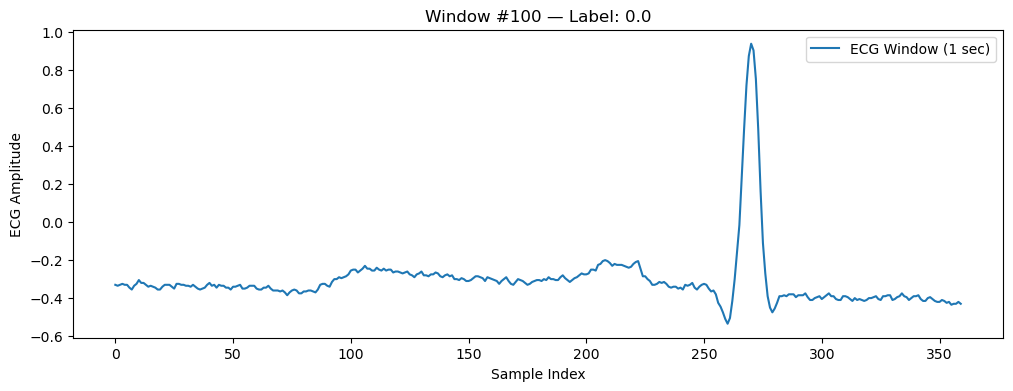

In [129]:
plt.figure(figsize=(12, 4))
plt.plot(X[100][:360], label="ECG Window (1 sec)")
plt.title(f"Window #100 — Label: {y[100]}")
plt.xlabel("Sample Index")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()

Shows a 1‑second window of ECG data taken from the combined 90‑minute signal. The tall spike near the end of the window is the QRS complex, which represents a normal heartbeat. The rest of the waveform consists of the baseline and smaller P and T waves that make up a typical cardiac cycle.

No abnormal heartbeat occurs in the 0.5‑second prediction horizon immediately after this window.


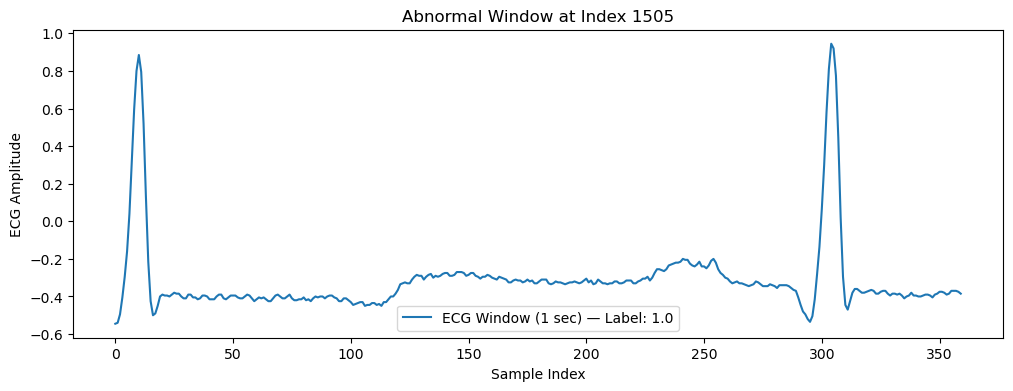

In [103]:
# Find an abnormal window
abnormal_indices = np.where(y == 1)[0]

if len(abnormal_indices) > 0:
    idx = abnormal_indices[0]  # first abnormal window
    plt.figure(figsize=(12, 4))
    plt.plot(X[idx][:360], label=f"ECG Window (1 sec) — Label: {y[idx]}")
    plt.title(f"Abnormal Window at Index {idx}")
    plt.xlabel("Sample Index")
    plt.ylabel("ECG Amplitude")
    plt.legend()
    plt.show()
else:
    print("No abnormal windows found.")

Shows a 1‑second segment of ECG that leads into an abnormal heartbeat.


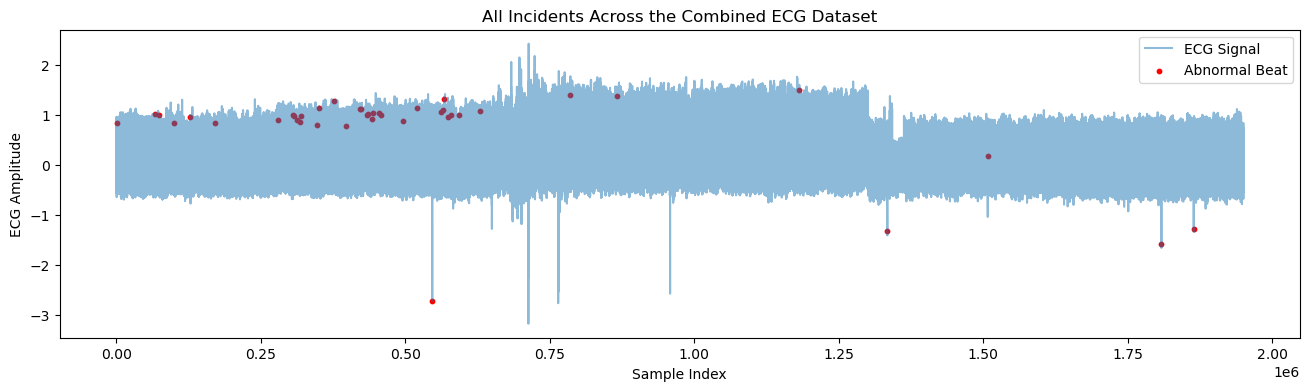

In [104]:
plt.figure(figsize=(16, 4))
plt.plot(signal, label="ECG Signal", alpha=0.5)

incident_points = np.where(incident == 1)[0]
plt.scatter(
    incident_points,
    signal[incident_points],
    color="red",
    s=10,
    label="Abnormal Beat"
)

plt.title("All Incidents Across the Combined ECG Dataset")
plt.xlabel("Sample Index")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()


This plot shows the entire 90‑minute ECG signal from all three records combined, with every detected abnormal beat marked in red. The blue waveform represents the continuous heart activity, while the red points highlight the exact moments where an arrhythmia occurred. 

In [105]:
unique, counts = np.unique(y, return_counts=True)
print("Window label counts:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count}")

Window label counts:
Label 0.0: 1942080
Label 1.0: 7380


- 0.0 → no abnormal beat in the next 0.5 seconds
- 1.0 → an abnormal beat occurs in the next 0.5 seconds

###### We have a highly imbalanced dataset

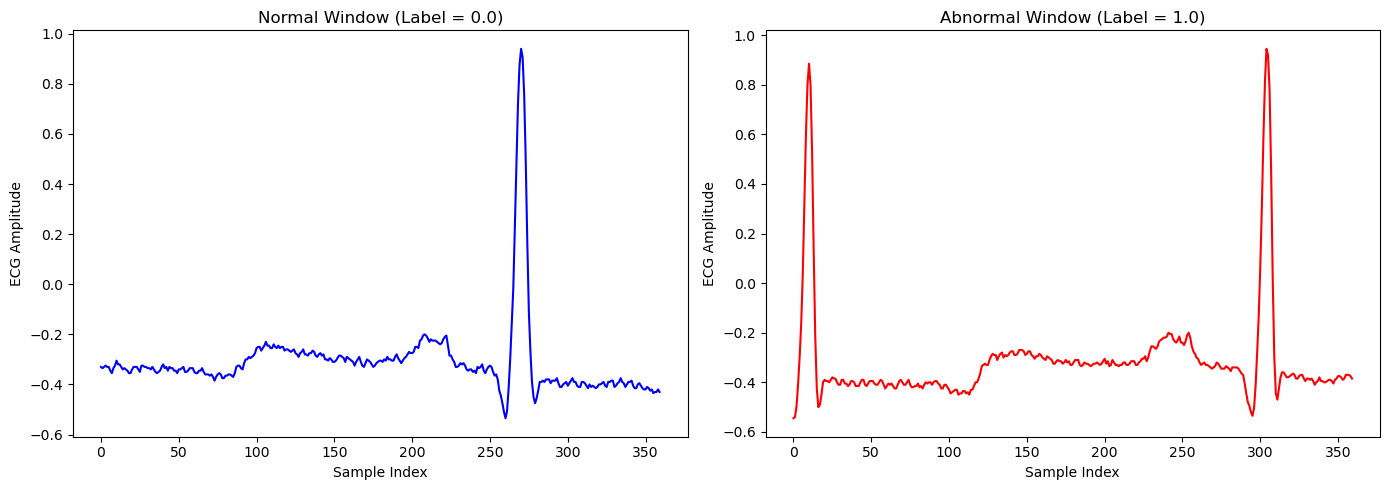

In [106]:
# Find one normal and one abnormal window
normal_idx = np.where(y == 0)[0][100]   # pick a normal window
abnormal_idx = np.where(y == 1)[0][0]   # first abnormal window

plt.figure(figsize=(14, 5))

# Normal window
plt.subplot(1, 2, 1)
plt.plot(X[normal_idx][:360], color="blue")
plt.title(f"Normal Window (Label = {y[normal_idx]})")
plt.xlabel("Sample Index")
plt.ylabel("ECG Amplitude")

# Abnormal window
plt.subplot(1, 2, 2)
plt.plot(X[abnormal_idx][:360], color="red")
plt.title(f"Abnormal Window (Label = {y[abnormal_idx]})")
plt.xlabel("Sample Index")
plt.ylabel("ECG Amplitude")

plt.tight_layout()
plt.show()

Side by Side graphs

## Split Data
- Training , testing and validation
- No shuffling to preserve time order


In [133]:
from sklearn.model_selection import train_test_split

# First split: Train vs Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Second split: Train vs Validation (from the training set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Testing samples:", X_test.shape)

print("Training labels distribution:", pd.Series(y_train).value_counts())
print("Validation labels distribution:", pd.Series(y_val).value_counts())
print("Testing labels distribution:", pd.Series(y_test).value_counts())

Training samples: (1247654, 364)
Validation samples: (311914, 364)
Testing samples: (389892, 364)
Training labels distribution: 0.0    1242038
1.0       5616
Name: count, dtype: int64
Validation labels distribution: 0.0    310510
1.0      1404
Name: count, dtype: int64
Testing labels distribution: 0.0    389532
1.0       360
Name: count, dtype: int64



## Standard Scaling
- Scales features to mean 0, std 1

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training sample (first row):")
print(X_train_scaled[0][:10])

Scaled training sample (first row):
[-0.58619387 -0.60836316 -0.65292135 -0.63065883 -0.67525179 -0.60841973
 -0.56382065 -0.58607316 -0.58611626 -0.63069933]


In [135]:
num_normal = (y_train == 0).sum()
num_abnormal = (y_train == 1).sum()

print("Normal:", num_normal)
print("Abnormal:", num_abnormal)


Normal: 1242038
Abnormal: 5616


## Train XG Boost
 It trains much faster than a Balanced Random Forestimproves both recall and precision after threshold tuning. 

In [110]:
## Train Balanced Random Forest
# Handles class imbalance in incidents but very slow

# from imblearn.ensemble import BalancedRandomForestClassifier

# model = BalancedRandomForestClassifier(
#     n_estimators=300,
#     sampling_strategy="auto",
#     class_weight={0:1, 1:5}
# )

# missing an abnormal beat is 5× more costly than a false alarm.

In [139]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

In [140]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="logloss",
    tree_method="hist"
)

## Model Predictions and Threshold
- `y_pred`: predicted class
- `y_prob`: predicted probability of incident



In [141]:
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

print("First 20 predictions:", y_pred[:20])
print("First 20 probabilities:", y_prob[:20])
print("First 20 probabilities:", y_val_prob[:20])

First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First 20 probabilities: [0.00809775 0.00886819 0.00785008 0.00737507 0.00967659 0.00976403
 0.01127619 0.011883   0.01665834 0.01816185 0.01781078 0.01868455
 0.01557912 0.01303279 0.01596927 0.01498175 0.01641932 0.01618027
 0.01824761 0.01789441]
First 20 probabilities: [1.1319116e-02 9.3119740e-01 1.1727423e-02 1.7331844e-02 7.6655567e-02
 1.2742501e-02 1.9242721e-04 1.6724233e-01 1.7138064e-02 1.7666562e-02
 7.3354418e-04 5.8154154e-01 2.3340287e-03 1.4320067e-02 2.9112415e-02
 8.6746627e-04 4.6549246e-01 6.0090080e-02 4.0340951e-01 2.9530481e-03]


In [143]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Recall (threshold=0.5):", recall_score(y_test, y_pred))
print("Precision (threshold=0.5):", precision_score(y_test, y_pred))

# At what probability should I trigger an alert?

def evaluate_threshold(probabilities, true_labels, threshold):
    preds = (probabilities >= threshold).astype(int)

#- If probability ≥ threshold → predict 1 (alert)
#- If probability < threshold → predict 0 (no alert)

    precision = precision_score(true_labels, preds, zero_division=0)
    recall = recall_score(true_labels, preds, zero_division=0)
    f1 = f1_score(true_labels, preds, zero_division=0)
    
    return precision, recall, f1

thresholds = [round(t, 2) for t in np.linspace(0.05, 0.5, 20)]
print("Threshold | Precision | Recall | F1")

best_recall = 0
best_threshold = 0


for thr in thresholds:
    p, r, f = evaluate_threshold(y_val_prob, y_val, thr)
    print(f"{thr:9.2f} | {p:9.3f} | {r:6.3f} | {f:6.3f}")

    if r > best_recall:
        best_recall = r
        best_threshold = thr

print("\nBest threshold based on recall:", best_threshold)
print("Best recall:", best_recall)


Recall (threshold=0.5): 0.0
Precision (threshold=0.5): 0.0
Threshold | Precision | Recall | F1
     0.05 |     0.016 |  1.000 |  0.031
     0.07 |     0.018 |  1.000 |  0.036
     0.10 |     0.021 |  1.000 |  0.042
     0.12 |     0.023 |  1.000 |  0.045
     0.14 |     0.025 |  1.000 |  0.049
     0.17 |     0.027 |  1.000 |  0.053
     0.19 |     0.029 |  1.000 |  0.057
     0.22 |     0.032 |  1.000 |  0.062
     0.24 |     0.034 |  1.000 |  0.065
     0.26 |     0.036 |  1.000 |  0.069
     0.29 |     0.039 |  0.999 |  0.075
     0.31 |     0.041 |  0.999 |  0.079
     0.33 |     0.043 |  0.999 |  0.083
     0.36 |     0.047 |  0.997 |  0.090
     0.38 |     0.050 |  0.996 |  0.095
     0.41 |     0.055 |  0.996 |  0.104
     0.43 |     0.058 |  0.995 |  0.110
     0.45 |     0.062 |  0.994 |  0.117
     0.48 |     0.068 |  0.993 |  0.128
     0.50 |     0.073 |  0.992 |  0.136

Best threshold based on recall: 0.05
Best recall: 1.0


In [160]:
y_prob.max()

np.float32(0.062917575)

In [161]:
for t in [0.01, 0.02, 0.03, 0.04, 0.05]:
    y_pred = (y_prob >= t).astype(int)
    print(t, sum(y_pred))

0.01 62786
0.02 6931
0.03 1020
0.04 152
0.05 26


In [164]:
for t in [0.03, 0.04, 0.05]:
    y_pred = (y_prob >= t).astype(int)
    print("Threshold:", t)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print()


Threshold: 0.03
Precision: 0.0
Recall: 0.0
F1: 0.0
[[388512   1020]
 [   360      0]]

Threshold: 0.04
Precision: 0.0
Recall: 0.0
F1: 0.0
[[389380    152]
 [   360      0]]

Threshold: 0.05
Precision: 0.0
Recall: 0.0
F1: 0.0
[[389506     26]
 [   360      0]]



##### Precision:
Of all alerts raised, how many were correct?
##### Recall: 
Of all true incidents, how many were caught?
##### F1 Score
Balance of precision + recall.
High F1 = good overall alerting performance.

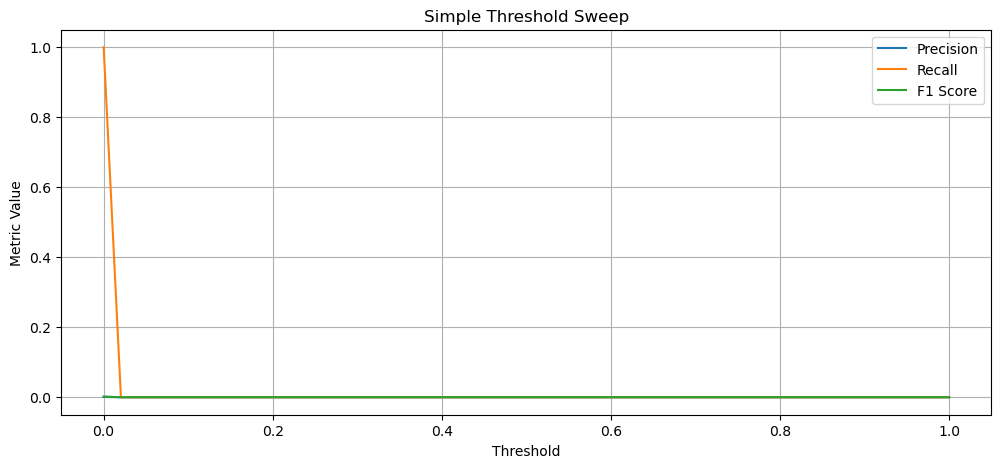

In [165]:
precisions = []
recalls = []
f1s = []
ths = np.linspace(0,1,50)

for thr in ths:
    p, r, f = evaluate_threshold(y_prob, y_test, thr)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

plt.figure(figsize=(12,5))
plt.plot(ths, precisions, label="Precision")
plt.plot(ths, recalls, label="Recall")
plt.plot(ths, f1s, label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Simple Threshold Sweep")
plt.legend()
plt.grid(True)
plt.show()

In [159]:
# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Apply tuned threshold
threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

# Evaluate
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))

Precision: 0.0
Recall: 0.0
F1: 0.0


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Inspect Feature Importance
Shows which parts of the ECG window or statistical features are most relevant.
  

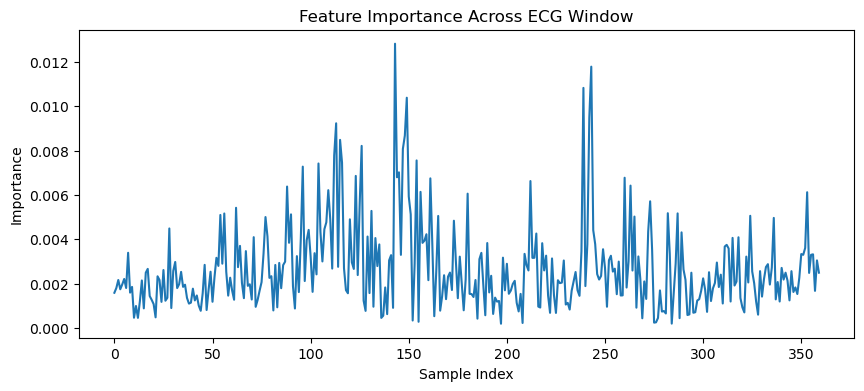

In [146]:
importances = model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances[:360])
plt.title("Feature Importance Across ECG Window")
plt.xlabel("Sample Index")
plt.ylabel("Importance")
plt.show()


## Compute ROC-AUC and PR-AUC
These metrics are appropriate for imbalanced incident prediction tasks.

In [155]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc)
print("PR-AUC:", pr)

ROC-AUC: 0.6331899775457044
PR-AUC: 0.001295810149590968


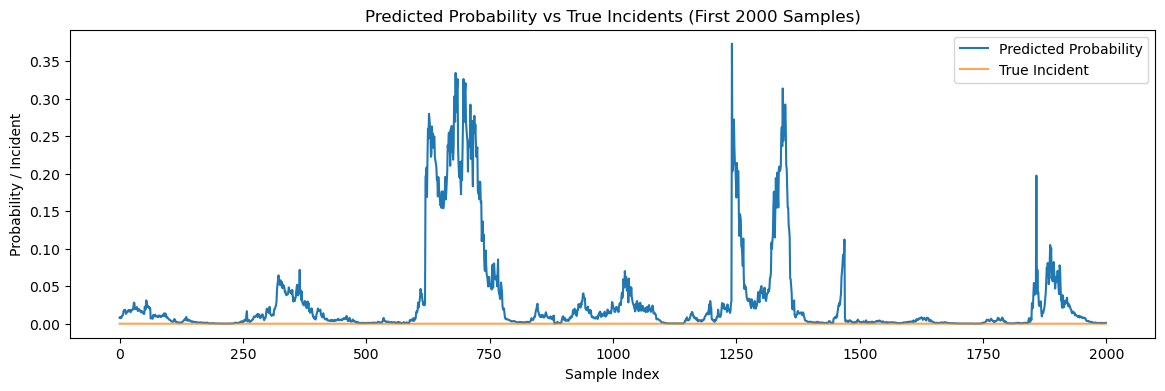

In [156]:
plt.figure(figsize=(14, 4))
plt.plot(y_prob[:2000], label="Predicted Probability")
plt.plot(y_test[:2000], label="True Incident", alpha=0.7)
plt.title("Predicted Probability vs True Incidents (First 2000 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Probability / Incident")
plt.legend()
plt.show()

- Blue = model’s predicted probability
- Orange = true incident (0 or 1)

The model’s probability rises during the true incident, showing it detects the pattern,but the values stay low (~0.2–0.3). This explains why high thresholds fail and why more data is needed for stronger, more reliable predictions.

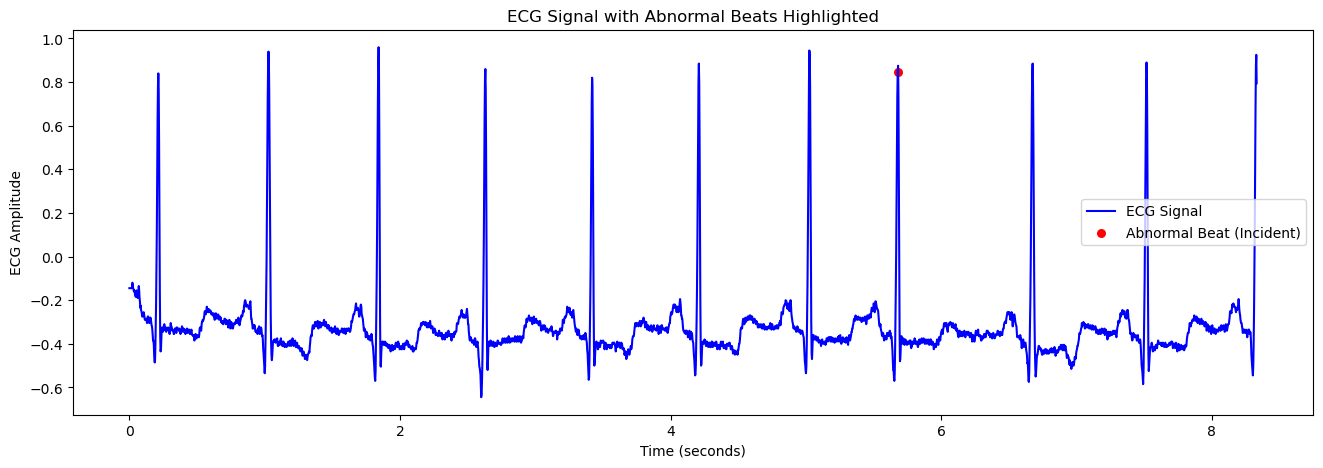

In [149]:
segment = df.iloc[:3000]

plt.figure(figsize=(16, 5))
plt.plot(segment["time"], segment["ecg"], label="ECG Signal", color="blue")

# Plot incidents (abnormal beats)
incident_points = segment[segment["incident"] == 1]
plt.scatter(
    incident_points["time"],
    incident_points["ecg"],
    color="red",
    label="Abnormal Beat (Incident)",
    s=30
)

plt.title("ECG Signal with Abnormal Beats Highlighted")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.show()
